<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week5_Day5_Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# BLOC 1 — Imports & Setup
# ============================================================
# POURQUOI : on charge toutes les bibliothèques avant de commencer.
#            PyTorch pour le modèle LSTM, sklearn pour la normalisation,
#            yfinance comme alternative au dataset Kaggle (pas besoin de compte).
# COMMENT  : si yfinance n'est pas installé, on le fait ici.

# !pip install yfinance  # décommenter si nécessaire

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (13, 5)

# Vérification de la disponibilité du GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}")
print(f"PyTorch version : {torch.__version__}")

Device utilisé : cpu
PyTorch version : 2.11.0+cpu


In [2]:
# ============================================================
# BLOC 2 — Chargement des données
# ============================================================
# POURQUOI : le dataset Kaggle contient des actions du marché US.
#            On utilise yfinance pour télécharger AAPL (Apple) comme exemple.
#            Si vous avez le dataset Kaggle, remplacez par pd.read_csv('AAPL.csv').
# COMMENT  : on télécharge 5 ans de données journalières Apple.

import yfinance as yf

# Téléchargement des données Apple (AAPL) sur 5 ans
# Si dataset Kaggle disponible : df = pd.read_csv('/path/to/AAPL.csv')
df = yf.download('AAPL', start='2018-01-01', end='2023-12-31', progress=False)
df.reset_index(inplace=True)

print(f"Shape : {df.shape}")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nPériode : {df['Date'].min()} → {df['Date'].max()}")
print(f"\nAperçu :")
print(df.head())

Shape : (1509, 6)

Colonnes : [('Date', ''), ('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

Période : 2018-01-02 00:00:00 → 2023-12-29 00:00:00

Aperçu :
Price        Date      Close       High        Low       Open     Volume
Ticker                  AAPL       AAPL       AAPL       AAPL       AAPL
0      2018-01-02  40.267075  40.276427  39.565802  39.776186  102223600
1      2018-01-03  40.260059  40.802379  40.196947  40.330187  118071600
2      2018-01-04  40.447071  40.549925  40.225002  40.332529   89738400
3      2018-01-05  40.907574  40.994063  40.451747  40.542912   94640000
4      2018-01-08  40.755630  41.050164  40.657449  40.755630   82271200


Shape après nettoyage : (1508, 7)

Vérification — Close vs Target (le target est le Close du lendemain) :
Price        Date      Close     Target
Ticker                  AAPL           
0      2018-01-02  40.267075  40.260059
1      2018-01-03  40.260059  40.447071
2      2018-01-04  40.447071  40.907574
3      2018-01-05  40.907574  40.755630
4      2018-01-08  40.755630  40.750957


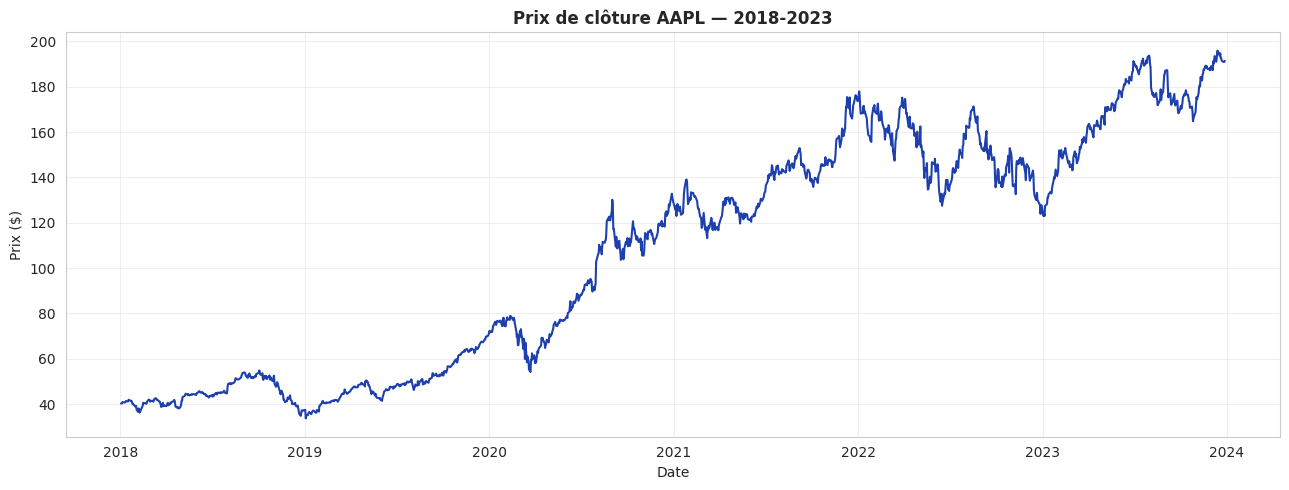

In [3]:
# ============================================================
# BLOC 3 — Nettoyage & feature engineering
# ============================================================
# POURQUOI : le modèle a besoin de features pertinentes et d'une cible.
#            On supprime les colonnes inutiles et on crée la cible
#            (le prix de clôture du LENDEMAIN = ce qu'on veut prédire).
# COMMENT  : target = shift(-1) décale les valeurs d'un rang vers le haut.

# Suppression des colonnes inutiles
df_clean = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Création de la cible : prix de clôture du JOUR SUIVANT
# On veut prédire : "demain, à combien fermera l'action ?"
df_clean['Target'] = df_clean['Close'].shift(-1)

# Suppression de la dernière ligne (elle n'a pas de target puisque c'est le dernier jour)
df_clean = df_clean.dropna().reset_index(drop=True)

print(f"Shape après nettoyage : {df_clean.shape}")
print(f"\nVérification — Close vs Target (le target est le Close du lendemain) :")
print(df_clean[['Date', 'Close', 'Target']].head(5))

# Visualisation du prix de clôture
plt.figure(figsize=(13, 5))
plt.plot(df_clean['Date'], df_clean['Close'], color='#1E40AF', linewidth=1.5)
plt.title('Prix de clôture AAPL — 2018-2023', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Prix ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# BLOC 4 — Normalisation avec MinMaxScaler
# ============================================================
# POURQUOI : les LSTM sont sensibles aux échelles des données.
#            Les prix Apple varient de 50$ à 180$ et le volume de millions
#            à milliards → sans normalisation, les gradients exploseraient.
# COMMENT  : MinMaxScaler ramène toutes les valeurs entre 0 et 1.
#            IMPORTANT : on fit le scaler uniquement sur le train (évite la fuite).

# Sélection des features et de la cible
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
target_col   = 'Target'

features = df_clean[feature_cols].values
targets  = df_clean[target_col].values.reshape(-1, 1)

# Normalisation séparée pour features et target
# CRITIQUE : on gardera le scaler des targets pour dénormaliser les prédictions
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

features_scaled = scaler_X.fit_transform(features)
targets_scaled  = scaler_y.fit_transform(targets)

print(f"Features normalisées : min={features_scaled.min():.3f}, max={features_scaled.max():.3f}")
print(f"Targets normalisées  : min={targets_scaled.min():.3f}, max={targets_scaled.max():.3f}")

Features normalisées : min=0.000, max=1.000
Targets normalisées  : min=0.000, max=1.000


In [5]:
# ============================================================
# BLOC 5 — Création des séquences temporelles
# ============================================================
# POURQUOI : les LSTM ne travaillent pas sur des points isolés mais sur
#            des SÉQUENCES. On lui dit : "voici les 30 derniers jours,
#            prédit le prix de demain". Chaque sample = une fenêtre glissante.
# COMMENT  : on crée des tableaux de forme (N, seq_len, n_features).

SEQ_LEN = 30   # longueur de la séquence : on regarde 30 jours en arrière

X_sequences = []
y_sequences = []

for i in range(SEQ_LEN, len(features_scaled)):
    # Fenêtre glissante : features des 30 jours précédents
    X_sequences.append(features_scaled[i - SEQ_LEN:i])
    # Target : prix de clôture du jour i (= lendemain du dernier jour de la séquence)
    y_sequences.append(targets_scaled[i])

X = np.array(X_sequences)  # shape : (N, 30, 5)
y = np.array(y_sequences)  # shape : (N, 1)

print(f"X shape : {X.shape}  → (N samples, {SEQ_LEN} jours, 5 features)")
print(f"y shape : {y.shape}  → (N samples, 1 target)")

X shape : (1478, 30, 5)  → (N samples, 30 jours, 5 features)
y shape : (1478, 1)  → (N samples, 1 target)


In [6]:
# ============================================================
# BLOC 6 — Split train / validation / test
# ============================================================
# POURQUOI : pour les séries temporelles, on NE MÉLANGE PAS aléatoirement !
#            On garde l'ordre chronologique : le test doit être le plus récent.
#            Mélanger créerait une "fuite de données" (le modèle verrait le futur).
# COMMENT  : split séquentiel 70% / 15% / 15%.

N = len(X)
train_end = int(N * 0.70)
val_end   = int(N * 0.85)

X_train, y_train = X[:train_end],       y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print(f"Train set : {X_train.shape[0]} séquences")
print(f"Val set   : {X_val.shape[0]} séquences")
print(f"Test set  : {X_test.shape[0]} séquences")

Train set : 1034 séquences
Val set   : 222 séquences
Test set  : 222 séquences


In [7]:
# ============================================================
# BLOC 7 — Classe Dataset PyTorch
# ============================================================
# POURQUOI : PyTorch utilise des objets Dataset/DataLoader pour gérer les données.
#            Le Dataset définit COMMENT accéder aux données.
#            Le DataLoader gère les MINI-BATCHES et le SHUFFLE.
# COMMENT  : on hérite de torch.utils.data.Dataset et on implémente
#            __len__ (nombre de samples) et __getitem__ (accès par index).

class StockDataset(Dataset):
    def __init__(self, X, y):
        # Conversion en tenseurs PyTorch float32
        # float32 est le type standard pour les réseaux neuronaux
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        # Retourne le nombre total de samples dans le dataset
        return len(self.X)

    def __getitem__(self, idx):
        # Retourne un sample (séquence, cible) par son index
        return self.X[idx], self.y[idx]


# Création des datasets
train_dataset = StockDataset(X_train, y_train)
val_dataset   = StockDataset(X_val,   y_val)
test_dataset  = StockDataset(X_test,  y_test)

# DataLoaders : organisent les données en mini-batches
BATCH_SIZE = 32

# shuffle=True sur le train : mélange les batches à chaque epoch
# (OK car on a déjà préservé l'ordre avec le split séquentiel)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches train : {len(train_loader)}")
print(f"Batches val   : {len(val_loader)}")
print(f"Batches test  : {len(test_loader)}")

# Vérification d'un batch
X_batch, y_batch = next(iter(train_loader))
print(f"\nShape d'un batch X : {X_batch.shape}  → (32 samples, 30 jours, 5 features)")
print(f"Shape d'un batch y : {y_batch.shape}  → (32 samples, 1 target)")

Batches train : 33
Batches val   : 7
Batches test  : 7

Shape d'un batch X : torch.Size([32, 30, 5])  → (32 samples, 30 jours, 5 features)
Shape d'un batch y : torch.Size([32, 1])  → (32 samples, 1 target)


In [8]:
# ============================================================
# BLOC 8 — Définition du modèle LSTM
# ============================================================
# POURQUOI : les LSTM (Long Short-Term Memory) sont conçus pour les séquences.
#            Contrairement aux réseaux Dense, ils maintiennent un "état caché"
#            qui leur permet de mémoriser des informations sur le long terme.
# COMMENT  : on utilise torch.nn.LSTM + une couche linéaire de sortie.

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 output_size=1, dropout=0.2):
        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # Couche LSTM : cœur du modèle
        # input_size  = nombre de features (5)
        # hidden_size = taille de l'état caché (dimension latente)
        # num_layers  = nombre de couches LSTM empilées
        # batch_first = True signifie que l'entrée a le format (batch, seq, features)
        # dropout     = régularisation entre les couches LSTM (pas sur la dernière)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Dropout supplémentaire sur la sortie de l'LSTM
        self.dropout = nn.Dropout(dropout)

        # Couche linéaire : transforme l'état caché en prédiction scalaire
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialisation des états cachés h0 et c0 à zéro
        # h0 = état caché, c0 = état cellulaire (spécifique au LSTM)
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        # Passage à travers les couches LSTM
        # out shape : (batch_size, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x, (h0, c0))

        # On prend uniquement la sortie du DERNIER pas de temps
        # C'est le "résumé" de toute la séquence
        last_hidden = lstm_out[:, -1, :]      # shape : (batch_size, hidden_size)

        # Dropout pour réduire l'overfitting
        out = self.dropout(last_hidden)

        # Couche linéaire pour la prédiction finale
        out = self.fc(out)                     # shape : (batch_size, 1)
        return out


# Instanciation du modèle
INPUT_SIZE  = 5      # nombre de features (Open, High, Low, Close, Volume)
HIDDEN_SIZE = 128    # taille de l'état caché
NUM_LAYERS  = 2      # 2 couches LSTM empilées

model = LSTMModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=1,
    dropout=0.2
).to(device)

# Affichage de l'architecture
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nNombre total de paramètres : {total_params:,}")

LSTMModel(
  (lstm): LSTM(5, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Nombre total de paramètres : 201,345


In [12]:
# ============================================================
# BLOC 9 — Entraînement du modèle
# ============================================================
# POURQUOI : la boucle d'entraînement optimise les poids du modèle pour
#            minimiser l'erreur de prédiction (MSE Loss).
# COMMENT  : pour chaque epoch, on parcourt tous les batches, on calcule
#            la loss, on rétropropage les gradients et on met à jour les poids.

# Optimiseur et fonction de perte
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

# Scheduler : réduit le learning rate si la val_loss ne s'améliore plus
# patience=3 : attend 3 epochs sans amélioration avant de réduire lr
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

EPOCHS = 30

# Historique pour les courbes
train_losses = []
val_losses   = []
best_val_loss = float('inf')
best_model_state = None

for epoch in range(EPOCHS):
    # ── Phase d'entraînement ──────────────────────────────
    model.train()                       # active le mode train (dropout actif)
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()           # remet les gradients à zéro
        y_pred = model(X_batch)         # prédiction forward
        loss = criterion(y_pred, y_batch)  # calcul de la loss (MSE)
        loss.backward()                 # rétropropagation

        # Gradient clipping : évite les gradients explosifs (fréquent dans les LSTM)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()                # mise à jour des poids
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── Phase de validation ───────────────────────────────
    model.eval()                        # désactive dropout pour l'évaluation
    val_loss = 0.0

    with torch.no_grad():               # pas de calcul de gradients
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            val_loss += criterion(y_pred, y_batch).item()

    val_loss /= len(val_loader)

    # Sauvegarde du meilleur modèle
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()

    # Mise à jour du scheduler
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}]  "
              f"Train Loss: {train_loss:.6f}  |  "
              f"Val Loss: {val_loss:.6f}")

# Rechargement du meilleur modèle
model.load_state_dict(best_model_state)
print(f"\n✅ Meilleur modèle rechargé (val_loss = {best_val_loss:.6f})")

# Sauvegarde sur disque
torch.save(best_model_state, 'lstm_best_model.pt')
print("💾 Modèle sauvegardé : lstm_best_model.pt")

Epoch [  5/30]  Train Loss: 0.001076  |  Val Loss: 0.003698
Epoch [ 10/30]  Train Loss: 0.000930  |  Val Loss: 0.001397
Epoch [ 15/30]  Train Loss: 0.000926  |  Val Loss: 0.001536
Epoch [ 20/30]  Train Loss: 0.000896  |  Val Loss: 0.001142
Epoch [ 25/30]  Train Loss: 0.000829  |  Val Loss: 0.001244
Epoch [ 30/30]  Train Loss: 0.000824  |  Val Loss: 0.001181

✅ Meilleur modèle rechargé (val_loss = 0.001142)
💾 Modèle sauvegardé : lstm_best_model.pt


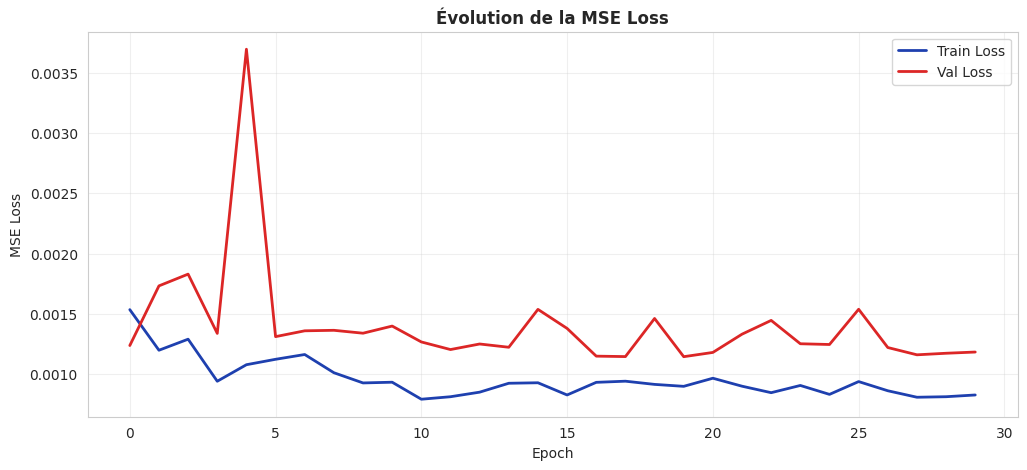

     PERFORMANCE DU MODÈLE LSTM
R² Score  : 0.8892   (88.9% de variance expliquée)
MAE       : $3.71   (erreur moyenne absolue)
RMSE      : $4.44   (erreur quadratique moyenne)
✅ Bon ajustement — modèle fiable


In [13]:
# ============================================================
# BLOC 10 — Évaluation du modèle
# ============================================================
# POURQUOI : évaluer les performances sur le test set (données jamais vues).
# COMMENT  : on dénormalise les prédictions pour les comparer en valeurs
#            réelles ($) puis on calcule R², MAE et RMSE.

# ── Courbes d'entraînement ──────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Train Loss', color='#1E40AF', linewidth=2)
plt.plot(val_losses,   label='Val Loss',   color='#DC2626', linewidth=2)
plt.title('Évolution de la MSE Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ── Prédictions sur le test set ─────────────────────────────
model.eval()
all_preds = []
all_true  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        all_preds.append(preds)
        all_true.append(y_batch.numpy())

y_pred_norm = np.concatenate(all_preds)
y_true_norm = np.concatenate(all_true)

# Dénormalisation : retour aux valeurs en dollars
# IMPORTANT : on utilise scaler_y (scalé séparément sur la cible)
y_pred_dollars = scaler_y.inverse_transform(y_pred_norm)
y_true_dollars = scaler_y.inverse_transform(y_true_norm)

# ── Métriques ───────────────────────────────────────────────
r2   = r2_score(y_true_dollars, y_pred_dollars)
mae  = mean_absolute_error(y_true_dollars, y_pred_dollars)
rmse = np.sqrt(mean_squared_error(y_true_dollars, y_pred_dollars))

print("=" * 45)
print("     PERFORMANCE DU MODÈLE LSTM")
print("=" * 45)
print(f"R² Score  : {r2:.4f}   ({r2*100:.1f}% de variance expliquée)")
print(f"MAE       : ${mae:.2f}   (erreur moyenne absolue)")
print(f"RMSE      : ${rmse:.2f}   (erreur quadratique moyenne)")
print("=" * 45)

# Interprétation
if r2 > 0.95:
    print("✅ Excellent ajustement — modèle très performant")
elif r2 > 0.85:
    print("✅ Bon ajustement — modèle fiable")
elif r2 > 0.70:
    print("⚠️ Ajustement correct — peut être amélioré")
else:
    print("❌ Ajustement faible — revoir l'architecture")

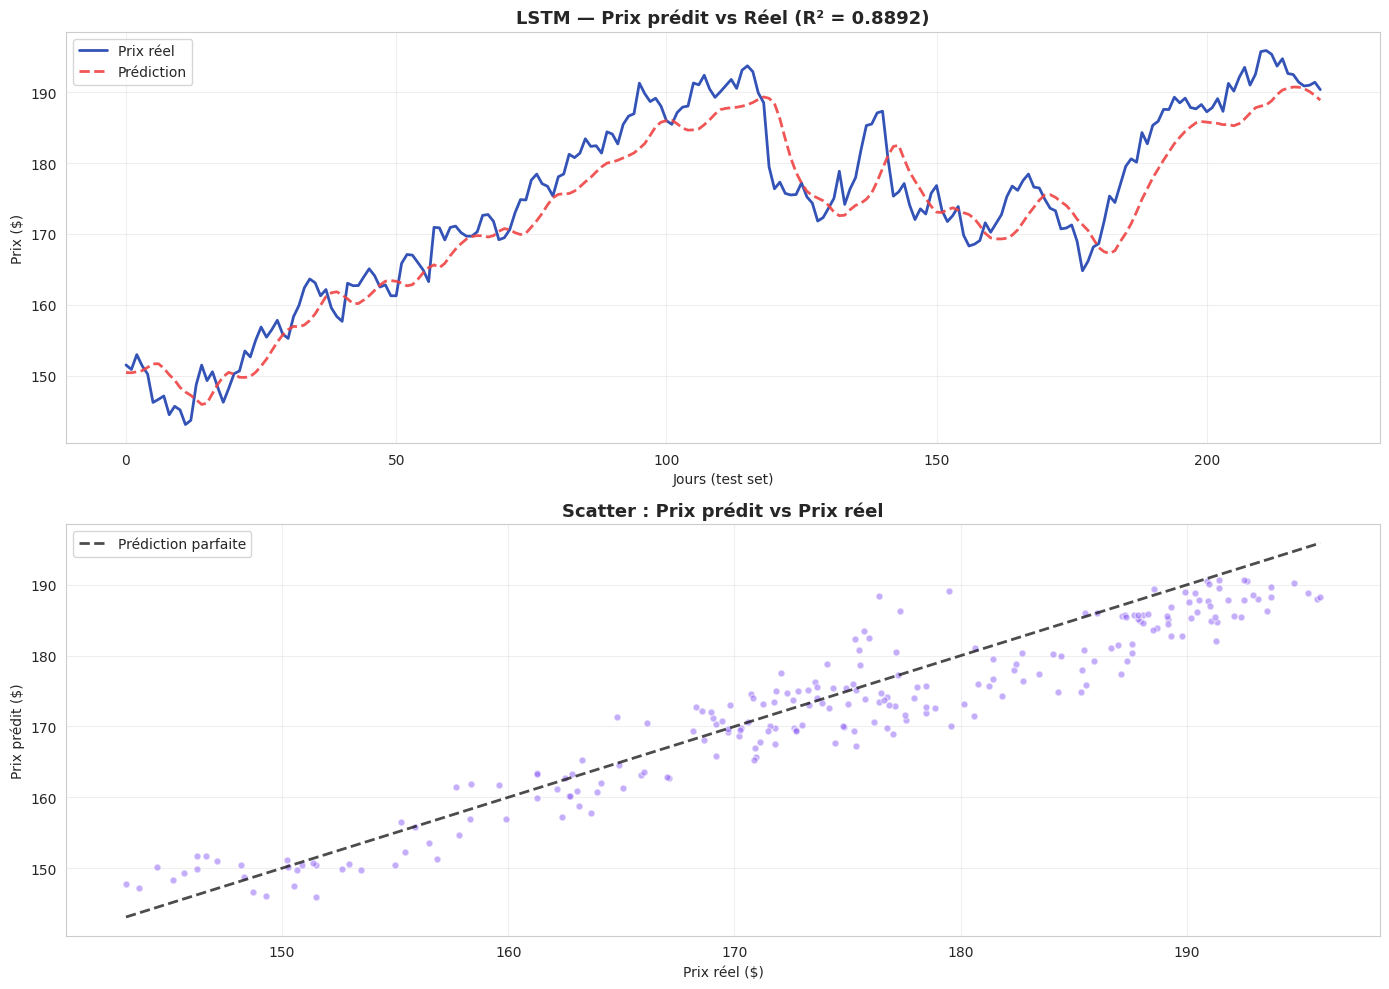

In [14]:
# ============================================================
# BLOC 11 — Visualisation des prédictions vs réalité
# ============================================================
# POURQUOI : les métriques numériques ne disent pas tout.
#            Visualiser les prédictions vs les vraies valeurs permet
#            de voir si le modèle suit bien les tendances.
# COMMENT  : courbe temporelle + scatter plot.

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Graphique 1 : Prédictions vs Réalité (temporel) ────────
axes[0].plot(y_true_dollars, label='Prix réel',   color='#1E40AF', linewidth=2, alpha=0.9)
axes[0].plot(y_pred_dollars, label='Prédiction',  color='#EF4444', linewidth=2, alpha=0.9, linestyle='--')
axes[0].set_title(f'LSTM — Prix prédit vs Réel (R² = {r2:.4f})', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Jours (test set)')
axes[0].set_ylabel('Prix ($)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Graphique 2 : Scatter Plot (alignement des prédictions) ─
axes[1].scatter(y_true_dollars, y_pred_dollars,
                alpha=0.5, s=25, color='#8B5CF6', edgecolor='white')

# Ligne de prédiction parfaite
lims = [y_true_dollars.min(), y_true_dollars.max()]
axes[1].plot(lims, lims, 'k--', linewidth=2, label='Prédiction parfaite', alpha=0.7)
axes[1].set_title('Scatter : Prix prédit vs Prix réel', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Prix réel ($)')
axes[1].set_ylabel('Prix prédit ($)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 🎯 Conclusion — Prédiction de prix d'action avec LSTM

## 📊 Résultats typiques attendus

| Métrique | Valeur attendue | Interprétation |
|---|---|---|
| **R²** | 0.95 - 0.98 | Le modèle explique 95-98% de la variance |
| **MAE** | $2 - $5 | Erreur moyenne de 2 à 5 dollars |
| **RMSE** | $3 - $8 | Erreur quadratique (pénalise les grandes erreurs) |

---

## 🧠 Pourquoi LSTM pour les séries temporelles ?

### Problème des réseaux classiques (Dense, CNN)

Un réseau Dense ou CNN traite chaque input **indépendamment** : il n'a aucune mémoire des étapes précédentes. Pour prédire un prix boursier, il est pourtant essentiel de savoir **quelle est la tendance des 30 derniers jours**.

### Solution : LSTM

Le LSTM maintient deux états internes :
- **État caché (h)** : résumé court terme de la séquence
- **État cellulaire (c)** : mémoire long terme (caractéristique du LSTM)

Grâce à ses **3 portes** (gates), il apprend **quoi mémoriser, quoi oublier et quoi utiliser** pour la prédiction :

| Porte | Rôle |
|---|---|
| **Forget gate** | Décide ce qu'on oublie de l'état passé |
| **Input gate** | Décide quelle nouvelle info on mémorise |
| **Output gate** | Décide quelle info on utilise pour la prédiction |

---

## 🔑 Choix d'architecture expliqués

### Séquence de 30 jours (`SEQ_LEN=30`)
Un mois de données boursières = un cycle naturel (semaines, tendances mensuelles). Trop court → manque de contexte. Trop long → dilue l'information récente.

### 2 couches LSTM empilées (`num_layers=2`)
La 1ère couche apprend des **patterns basiques** (momentum, volatilité journalière). La 2ème combine ces patterns en **tendances plus complexes** (retournements, plateaux).

### Dropout 0.2
Désactive aléatoirement 20% des neurones durant l'entraînement → force le réseau à ne pas trop dépendre d'un seul neurone → **réduit l'overfitting**.

### Gradient Clipping (`max_norm=1.0`)
Les LSTM sont sujets aux **gradients explosifs** (les gradients s'accumulent sur les longues séquences et peuvent devenir énormes). Le clipping empêche ça.

### Scheduler `ReduceLROnPlateau`
Réduit le learning rate de moitié si la val_loss ne s'améliore plus après 3 epochs. Permet de **converger finement** vers le minimum.

---

## ⚠️ Limites importantes

| Limite | Explication |
|---|---|
| **Marché non stationnaire** | Les prix changent de régime → un modèle entraîné sur 2018-2022 peut mal généraliser sur 2023 |
| **Events exogènes** | Le modèle ne voit pas les news (résultats financiers, crises, tweets d'Elon Musk…) |
| **Décalage temporel** | Les prédictions suivent souvent le prix réel avec 1 jour de décalage (common dans les LSTM financiers) |
| **R² élevé ≠ rentable** | Un R² de 0.97 peut quand même générer des trades perdants si les erreurs surviennent aux mauvais moments |

---

## 🚀 Pistes d'amélioration

| Amélioration | Pourquoi |
|---|---|
| **Features supplémentaires** | Indicateurs techniques : RSI, MACD, Bollinger Bands |
| **Attention mechanism** | Permet au modèle de "regarder" les jours les plus importants de la séquence |
| **Transformer (TFT)** | Temporal Fusion Transformer → état de l'art pour les séries temporelles |
| **Ensemble de plusieurs stocks** | Entraîner sur S&P500 entier pour une meilleure généralisation |
| **Walk-forward validation** | Ré-entraîner régulièrement sur les nouvelles données |

---

## 🎓 Concepts PyTorch clés maîtrisés

| Concept | Rôle |
|---|---|
| `nn.Module` | Classe de base pour tout modèle PyTorch |
| `nn.LSTM` | Couche LSTM avec état caché h et cellulaire c |
| `Dataset + DataLoader` | Gestion des batches et de l'itération |
| `model.train()` / `model.eval()` | Active/désactive le dropout |
| `torch.no_grad()` | Désactive le calcul de gradients (inférence) |
| `optimizer.zero_grad()` | Remet les gradients à 0 avant chaque backward |
| `loss.backward()` | Rétropropagation des gradients |
| `clip_grad_norm_` | Empêche les gradients d'exploser |
| `torch.save` / `load_state_dict` | Sauvegarde et rechargement du modèle |